# Решающее дерево


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import load_npz
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.metrics import *

In [ ]:
train = load_npz("x_train_tfidf.npz")
test = load_npz("x_test_tfidf.npz")

X_train = train[:, :-1]
y_train = train[:, -1].toarray().ravel()

X_test = test[:, :-1]
y_test = test[:, -1].toarray().ravel()

### 2. Подбор гиперпараметра max_depth

In [ ]:
depths = [3, 5, 10, 15, 20, 30]
m = []
for d in depths:
    model = DecisionTreeClassifier( max_depth=d, random_state=67)
    score = cross_val_score(  model, X_train, y_train, cv=3, scoring='roc_auc')
    m.append(score.mean())
    print(d, score.mean())

3 0.9255890750396505
5 0.9461466836165117
10 0.9514784084074611
15 0.946120863351538
20 0.9363007240997789
30 0.9236177641048533


In [ ]:
best_i = np.argmax(m)
best_depth = depths[best_i]
print("Лучшая глубина =", best_depth)

Лучшая глубина = 10


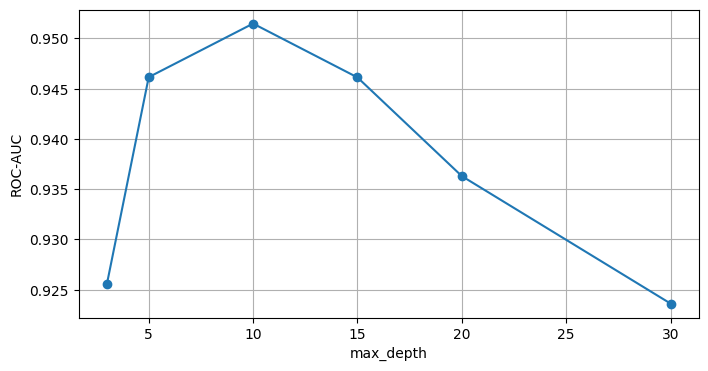

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(depths, m, 'o-')
plt.xlabel('max_depth')
plt.ylabel('ROC-AUC')
plt.grid(True)

### 3. Кривая обучения

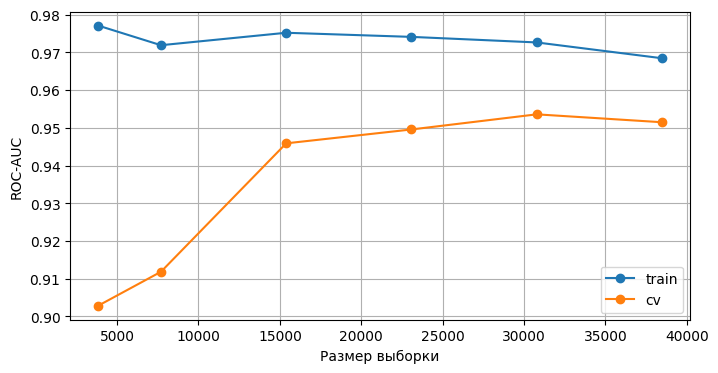

In [ ]:
model = DecisionTreeClassifier( max_depth=best_depth, random_state=67)

sizes, train_scores, val_scores = learning_curve(model, X_train,  y_train, train_sizes=[0.1, 0.2, 0.4, 0.6, 0.8, 1.0],  cv=3, scoring='roc_auc')
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
plt.figure(figsize=(8, 4))
plt.plot(sizes, train_mean, 'o-', label='train')
plt.plot(sizes, val_mean, 'o-', label='cv')
plt.xlabel('Размер выборки')
plt.ylabel('ROC-AUC')
plt.legend()
plt.grid()

### 4. Обучение финальной модели

In [ ]:
tree = DecisionTreeClassifier(max_depth=best_depth, random_state=67)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
y_prob = tree.predict_proba(X_test)[:, 1]

### 5. Оценка качества

In [ ]:
print(classification_report(y_test, y_pred, target_names=['Реальная', 'Фейковая']))

              precision    recall  f1-score   support

    Реальная       0.96      0.92      0.94      7006
    Фейковая       0.93      0.97      0.95      7421

    accuracy                           0.94     14427
   macro avg       0.95      0.94      0.94     14427
weighted avg       0.94      0.94      0.94     14427



In [ ]:
print("Accuracy =", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC =", round(roc_auc_score(y_test, y_pred), 4))

Accuracy = 0.9438
ROC-AUC = 0.9431


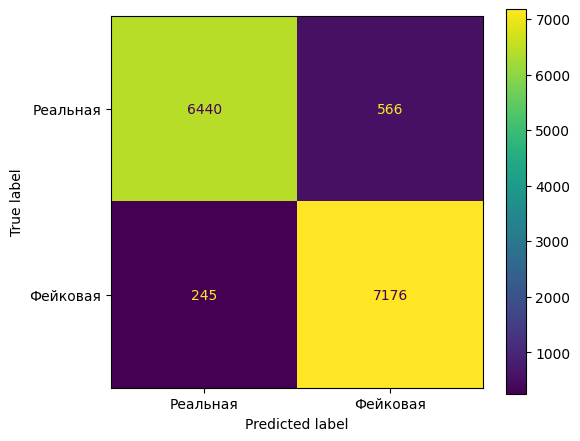

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),display_labels=['Реальная', 'Фейковая']).plot(ax=ax)

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
prec, rec, _ = precision_recall_curve( y_test, y_prob)
roc_auc = roc_auc_score(y_test,y_prob)
ap = average_precision_score( y_test, y_prob)

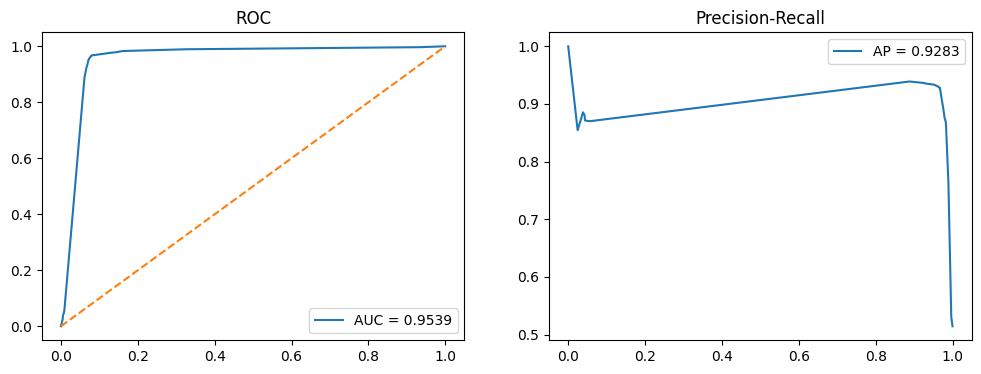

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
ax[0].plot([0, 1], [0, 1], '--')
ax[0].set_title('ROC')
ax[0].legend()
ax[1].plot(rec,prec,label=f'AP = {ap:.4f}')
ax[1].set_title('Precision-Recall')
ax[1].legend()

In [ ]:
print("ROC-AUC =", round(roc_auc, 4))
print("Average Precision =", round(ap, 4))

ROC-AUC = 0.9539
Average Precision = 0.9283


# Решающее дерево для категорий

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import load_npz
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

In [ ]:
train = load_npz("x_train_cat_tfidf.npz")
test = load_npz("x_test_cat_tfidf.npz")

X_train = train[:, :-1]
y_train = train[:, -1].toarray().ravel()

X_test = test[:, :-1]
y_test = test[:, -1].toarray().ravel()

In [ ]:
depths = [30, 40, 50, 60, 80, 100]
m = []
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test,classes=classes)
for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=67)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)
    roc_auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')
    m.append(roc_auc)
    print(d, roc_auc)

30 0.685517952662433
40 0.6992201339266105
50 0.7027013269182921
60 0.7031526226966804
80 0.7005837325560106
100 0.6986681759615252


In [ ]:
best_i = np.argmax(m)
best_depth = depths[best_i]
print("Лучшая глубина =", best_depth)

Лучшая глубина = 60


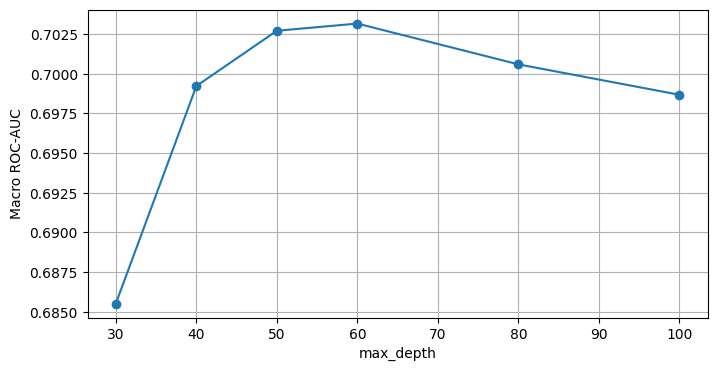

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(depths, m, 'o-')
plt.xlabel('max_depth')
plt.ylabel('Macro ROC-AUC')
plt.grid()

In [ ]:
tree = DecisionTreeClassifier(max_depth=best_depth, random_state=67)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
y_prob = tree.predict_proba(X_test)

In [ ]:
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test,classes=classes)
roc_auc = roc_auc_score(y_test_bin,y_prob,average='macro',multi_class='ovr')
print("Accuracy =", round(accuracy_score(y_test, y_pred), 4))
print("Macro ROC-AUC =", round(roc_auc, 4))

Accuracy = 0.3498
Macro ROC-AUC = 0.7032


In [ ]:
y_pred = tree.predict(X_test)
y_prob = tree.predict_proba(X_test)

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
classes = np.unique(y_train)
y_test_bin = label_binarize( y_test,classes=classes)
roc_auc_macro = roc_auc_score( y_test_bin,y_prob, average='macro', multi_class='ovr')
roc_auc_micro = roc_auc_score(y_test_bin,y_prob, average='micro', multi_class='ovr')
pr_auc_macro = average_precision_score(y_test_bin,y_prob,average='macro')
pr_auc_micro = average_precision_score( y_test_bin,y_prob,average='micro')
print("Macro ROC-AUC =", round(roc_auc_macro, 4))
print("Micro ROC-AUC =", round(roc_auc_micro, 4))
print("Macro PR-AUC =", round(pr_auc_macro, 4))
print("Micro PR-AUC =", round(pr_auc_micro, 4))

Macro ROC-AUC = 0.7032
Micro ROC-AUC = 0.8053
Macro PR-AUC = 0.1369
Micro PR-AUC = 0.2753
